# 実験03: 砂山モデル — 自己組織化臨界 (SOC)

Bak–Tang–Wiesenfeld モデル。1 粒ずつ砂を落とすだけで、系は**パラメータ調整なしに
臨界状態へ自己組織化**し、雪崩の大きさが**べき分布**になる。

ルール: 各点の高さ $z\ge4$ なら崩れ、$z\to z-4$、上下左右へ 1 粒ずつ。境界外へは散逸。
理論は `../../notes/self_organized_criticality.md` を参照。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import sandpile as sp

_jp = "/usr/share/fonts/truetype/fonts-japanese-gothic.ttf"
fm.fontManager.addfont(_jp)
plt.rcParams["font.family"] = fm.FontProperties(fname=_jp).get_name()
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110

L = 64
rng = np.random.default_rng(0)
print("格子サイズ", L, "x", L)

格子サイズ 64 x 64


## 1. 「自己組織化」を見る

空の格子から砂を落とし続けると、平均高さがひとりでに臨界値（2D では $\approx2.12$）へ
近づき、そこで止まる。**誰も臨界点に調整していない**のに、系が自分で臨界へ向かう
——これが self-*organized* criticality の核心。

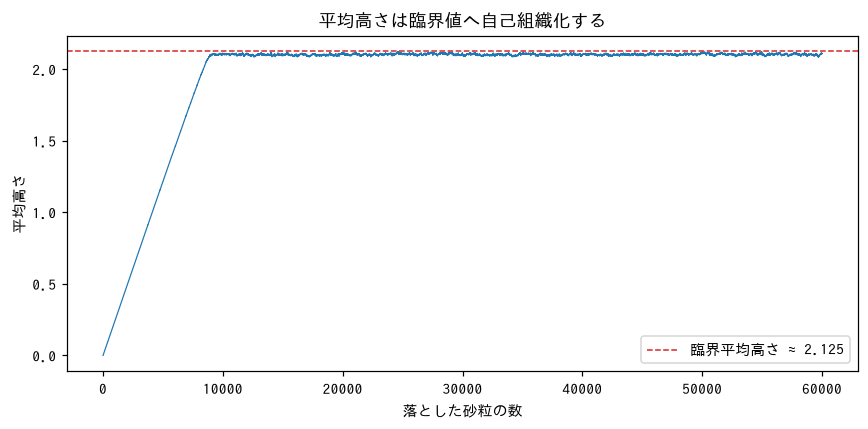

最終平均高さ: 2.11


In [2]:
z = sp.new_grid(L)
n_track = 60000
heights = np.empty(n_track)
for k in range(n_track):
    sp.add_grain(z, rng)
    sp.relax(z)
    heights[k] = z.mean()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(heights, lw=0.8)
ax.axhline(2.125, color="C3", ls="--", lw=1, label="臨界平均高さ ≈ 2.125")
ax.set_xlabel("落とした砂粒の数"); ax.set_ylabel("平均高さ")
ax.set_title("平均高さは臨界値へ自己組織化する")
ax.legend()
fig.tight_layout(); plt.show()
print("最終平均高さ:", round(heights[-1], 3))

## 2. 臨界状態の配置

臨界状態の砂山の高さ分布。フラクタル的な構造が見える。

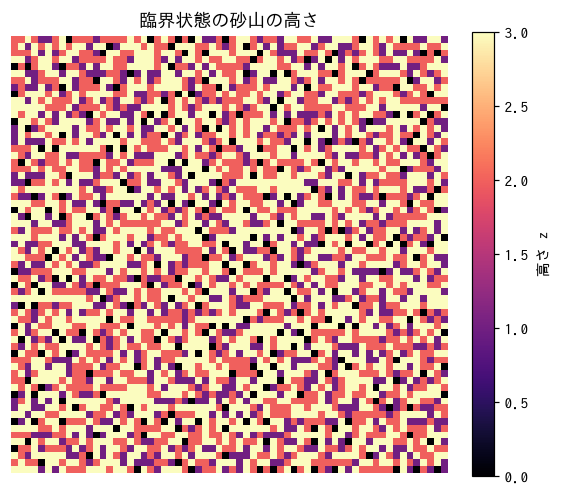

In [3]:
fig, ax = plt.subplots(figsize=(5.2, 5))
im = ax.imshow(z, cmap="magma", vmin=0, vmax=3)
ax.set_title("臨界状態の砂山の高さ"); ax.axis("off")
fig.colorbar(im, ax=ax, fraction=0.046, label="高さ z")
fig.tight_layout(); plt.show()

## 3. 雪崩統計を集める

臨界状態で多数の砂粒を落とし、各雪崩の **サイズ**（総崩れ回数）・**継続時間**・
**広がり（面積）** を記録する。

In [4]:
stats = sp.drive(z, 120000, rng, warmup=0)  # 既に臨界状態なので warmup 不要
s = stats["sizes"]; d = stats["durations"]; a = stats["areas"]
print(f"雪崩の数: {len(s)}")
print(f"サイズ  : min {s.min()}, max {s.max()}, mean {s.mean():.1f}")
print(f"継続時間: min {d.min()}, max {d.max()}, mean {d.mean():.1f}")

雪崩の数: 52351
サイズ  : min 1, max 14007, mean 351.7
継続時間: min 1, max 910, mean 39.4


## 4. べき分布（本実験の主役）

雪崩サイズ $s$ の分布が $P(s)\sim s^{-\tau}$ というべき則になる。両対数で直線。
**特徴的なスケールがない**（小さな雪崩も巨大な雪崩も同じ法則で起きる）= 臨界の指紋。
対数等間隔ビンで密度を推定し、傾きから指数 $\tau$ を測る。

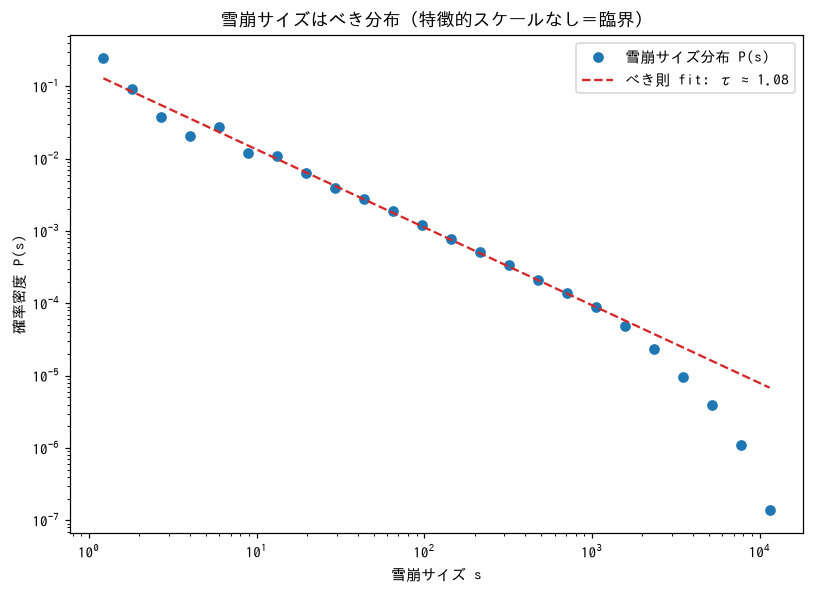

測定したべき指数 τ ≈ 1.08（2D BTW の報告値は手法・ビン取り依存で ≈1.0〜1.3）


In [5]:
def fit_powerlaw(values, lo_frac=0.0, hi_frac=1.0):
    c, dens = sp.logbin(values, n_bins=25)
    # 両端を避けて回帰（有限サイズの折れ曲がりを除く）
    i0 = int(len(c) * lo_frac); i1 = int(len(c) * hi_frac)
    lx, ly = np.log10(c[i0:i1]), np.log10(dens[i0:i1])
    slope, intercept = np.polyfit(lx, ly, 1)
    return c, dens, -slope, intercept

cs, ds_, tau, b = fit_powerlaw(s, 0.0, 0.7)
fig, ax = plt.subplots(figsize=(7.5, 5.5))
ax.loglog(cs, ds_, "o", ms=6, color="C0", label="雪崩サイズ分布 P(s)")
xx = np.array([cs.min(), cs.max()])
ax.loglog(xx, 10**b * xx**(-tau), "C3--", lw=1.5, label=f"べき則 fit: τ ≈ {tau:.2f}")
ax.set_xlabel("雪崩サイズ s"); ax.set_ylabel("確率密度 P(s)")
ax.set_title("雪崩サイズはべき分布（特徴的スケールなし＝臨界）")
ax.legend()
fig.tight_layout(); plt.show()
print(f"測定したべき指数 τ ≈ {tau:.2f}（2D BTW の報告値は手法・ビン取り依存で ≈1.0〜1.3）")

## 5. 継続時間と広がりもべき則

サイズだけでなく、雪崩の継続時間 $T$ と広がり（面積）$A$ も別々のべき則に従う。
複数の量が同時にべき則を示すのが臨界現象の典型。

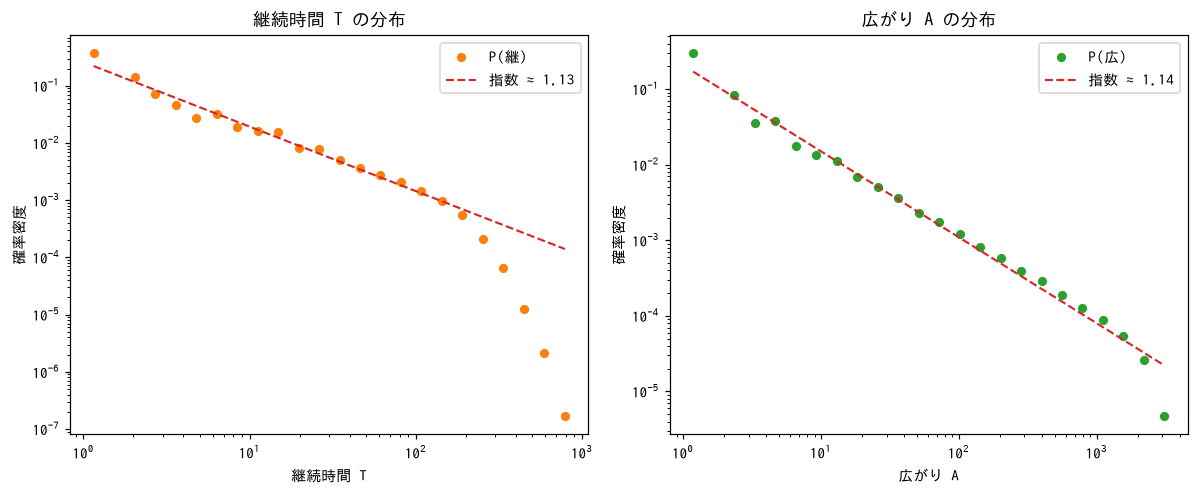

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.6))
for ax, vals, name, col in [(ax1, d, "継続時間 T", "C1"), (ax2, a, "広がり A", "C2")]:
    c, dens, ex, bb = fit_powerlaw(vals, 0.0, 0.65)
    ax.loglog(c, dens, "o", ms=5, color=col, label=f"P({name[0]})")
    xx = np.array([c.min(), c.max()])
    ax.loglog(xx, 10**bb * xx**(-ex), "C3--", lw=1.4, label=f"指数 ≈ {ex:.2f}")
    ax.set_xlabel(name); ax.set_ylabel("確率密度"); ax.legend()
    ax.set_title(f"{name} の分布")
fig.tight_layout(); plt.show()

## まとめ・気づき

- **自己組織化**: 平均高さが誰の調整もなしに臨界値へ向かう。外部駆動（砂を落とす）と
  内部緩和（雪崩）の分離だけで臨界が生まれる。
- **べき則 = 特徴的スケールの不在**: 雪崩サイズ・継続時間・広がりがすべてべき分布。
  「典型的な大きさ」が定義できない。小さな擾乱が時に系全体を巻き込む。
- 測定した指数 $\tau\approx1.1$（2D BTW の報告値は手法・ビン取り依存で $\approx1.0\text{–}1.3$）。
  指数の厳密な普遍値は今も議論があるが、「数桁にわたる直線＝特徴的スケールの不在」という
  定性的事実こそが SOC の本質。

### 金融との接続
- **ファットテール／ベキ則**: 株価変動・取引高・市場のクラッシュ規模がべき分布を示す事実は、
  市場が SOC 的な臨界状態にあるという仮説（市場の自己組織化臨界）と響き合う。
- **大事件に固有の原因は要らない**: 砂山の巨大雪崩に「特別な一粒」がないのと同じく、
  大暴落も「ありふれた一粒」が臨界状態で連鎖した結果かもしれない、という視点。
- 実験02（同期の相転移：制御パラメータを外から調整）と本実験（臨界へ自己組織化：調整不要）
  の対比が、複雑系における「臨界」の二つの現れ方を示す。